# Example chromatin and expression deconvolution

In this notebook, we show a small locus is deconvolved for both the chromatin and for transcripts within the window.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.config import load_default_chrom_configs
from src.combined_chromatin_model import CombinedChromatinModel

# Load the chromatin configuration objects containing
# information on the CLOCCS parameters, the timing, and the predetermined alpha
# parameter values
config1, config2 = load_default_chrom_configs()
print("Replicate 1's config parameters:")
for k, v in config1.params_dic.items():
    print('\t', k, v)
print("\nReplicate 1's experimental times:\n\t", config1.timepoints)

print("\n\nReplicate 2's config parameters:")
for k, v in config2.params_dic.items():
    print('\t', k, v)
print("\nReplicate 2's experimental times:\n\t", config2.timepoints)


Replicate 1's config parameters:
	 mu0 -26.7901
	 delta 8.1805
	 sigma0 10.9885
	 sigmav 0.1424
	 lambda 68.1914
	 gamma1 0.0041
	 gamma2 0.2547
	 halted 0.2245
	 alpha 34
	 num_g1_indices 62

Replicate 1's experimental times:
	 [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]


Replicate 2's config parameters:
	 mu0 -26.7901
	 delta 8.1805
	 sigma0 10.9885
	 sigmav 0.1424
	 lambda 68.1914
	 gamma1 0.0041
	 gamma2 0.2547
	 halted 0.2245
	 alpha 34
	 num_g1_indices 62

Replicate 2's experimental times:
	 [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]


In [3]:
# The loading and saving of data for the selected locus
# will be stored in a pre-filled output directory
example_output_dir = 'output/example'

# Load the chromatin model that will perform the deconvolution
combined_model = CombinedChromatinModel(config1=config1, config2=config2,
                                       output_dir=example_output_dir)

# We'll select the window around CLB5's transcription start site. The chromatin in 
# the promoter for CLB5 has interesting dynamics
chrom = 16
mnase_span = (774800, 776000)
combined_model.load_mnase_span(chrom, mnase_span, 
    mnase_output_directory=f'{example_output_dir}/mnase/')

Loading chromosome reads: 16
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 1199) to (16, 26, 120)
Loading chromosome reads: 16
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 1199) to (15, 26, 120)


In [4]:
# Setup with default parameters and deconvolve the chromatin
combined_model.setup_deconv_model(copy_correct=False)
combined_model.deconvolve(gamma=0.06, kappa=0.01)

Loading copy correction N, Fr, B from output/example
Disabling copy correction, using identity functions for N, b, and fr
0/3120 - 00:00:00.001
500/3120 - 00:00:07.563
1000/3120 - 00:01:18.906
1500/3120 - 00:02:41.937
2000/3120 - 00:04:09.889
2500/3120 - 00:05:37.439
3000/3120 - 00:06:58.702
Completed - 00:07:09.510


In [5]:
from pipeline.CombinedDeconvolveGeneExpressionRunner import \
    CombinedDeconvolveGeneExpressionRunner
from src.utils import mkdir_safe

# The expression deconvolution is encapsulated within a runner, which contains
# the code to compute the optimal gamma.
expression_runner = CombinedDeconvolveGeneExpressionRunner(example_output_dir)
_ = expression_runner.deconvolve_gene_optimal_gamma('CLB5', kappa=0.01)
clb5_f = expression_runner.expression_find_gamma.retrieve_solution()

# Save the deconvolved expression to disk
np.save(f'{example_output_dir}/genes_deconvolution/YPR120C_CLB5.npy', clb5_f)

Text(0.5, 1.07, 'Raw $\\it{CLB5}$ expression')

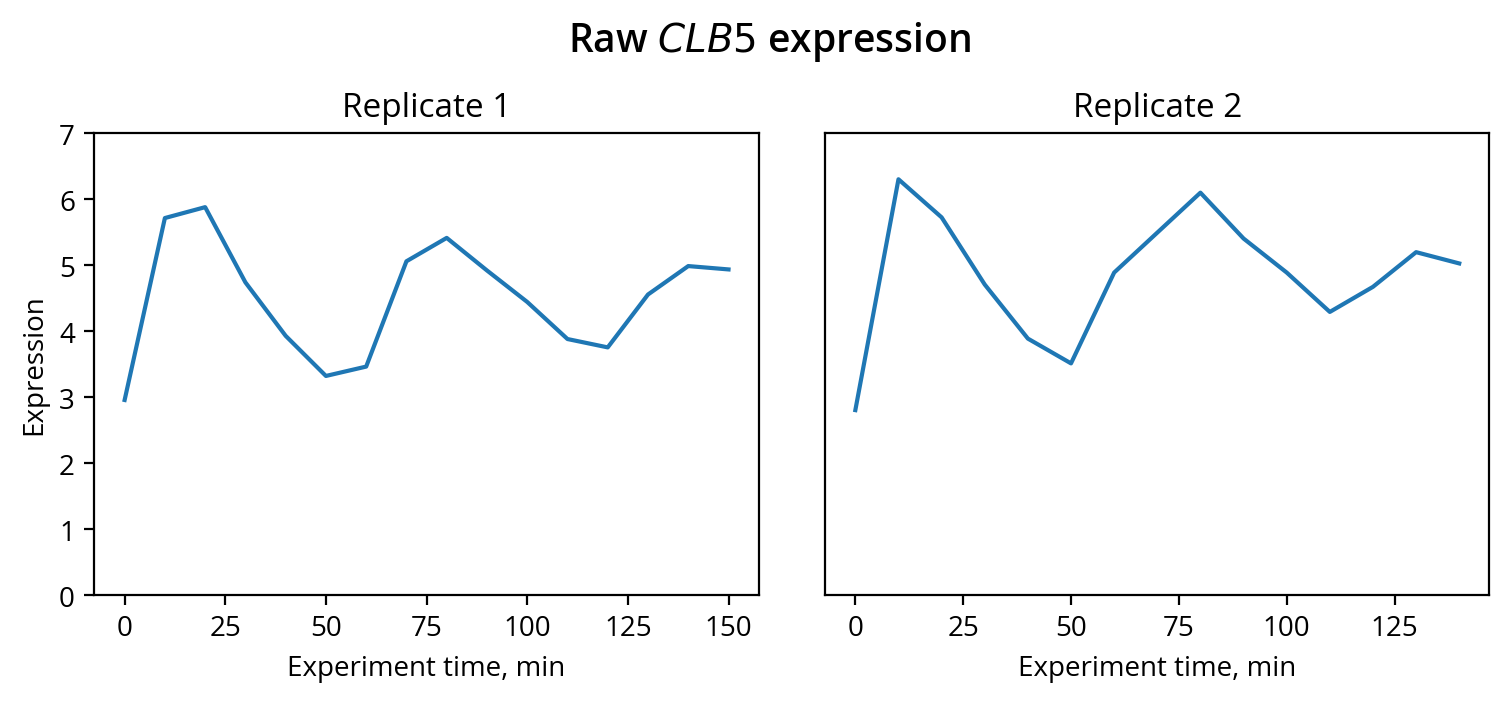

In [6]:
# Plot the raw expression for comparison

combined_g = expression_runner.expression_find_gamma.deconvolution_solver.g
expression_tps_rep1 = expression_runner.config1.timepoints
expression_tps_rep2 = expression_runner.config2.timepoints
rep1_g_raw = combined_g[:len(expression_tps_rep1)]
rep2_g_raw = combined_g[len(expression_tps_rep1):]

plt.figure(figsize=(9, 3))
plt.subplot(1, 2, 1)
plt.plot(expression_tps_rep1, rep1_g_raw)
plt.title("Replicate 1")
plt.ylim(0, 7)
plt.xlabel("Experiment time, min")
plt.ylabel("Expression")

plt.subplot(1, 2, 2)
plt.plot(expression_tps_rep2, rep2_g_raw)
plt.title("Replicate 2")
plt.ylim(0, 7)
plt.yticks([])
plt.subplots_adjust(wspace=0.1)
plt.xlabel("Experiment time, min")

plt.suptitle("Raw $\\it{CLB5}$ expression", fontweight='demi', fontsize=14, y=1.07)


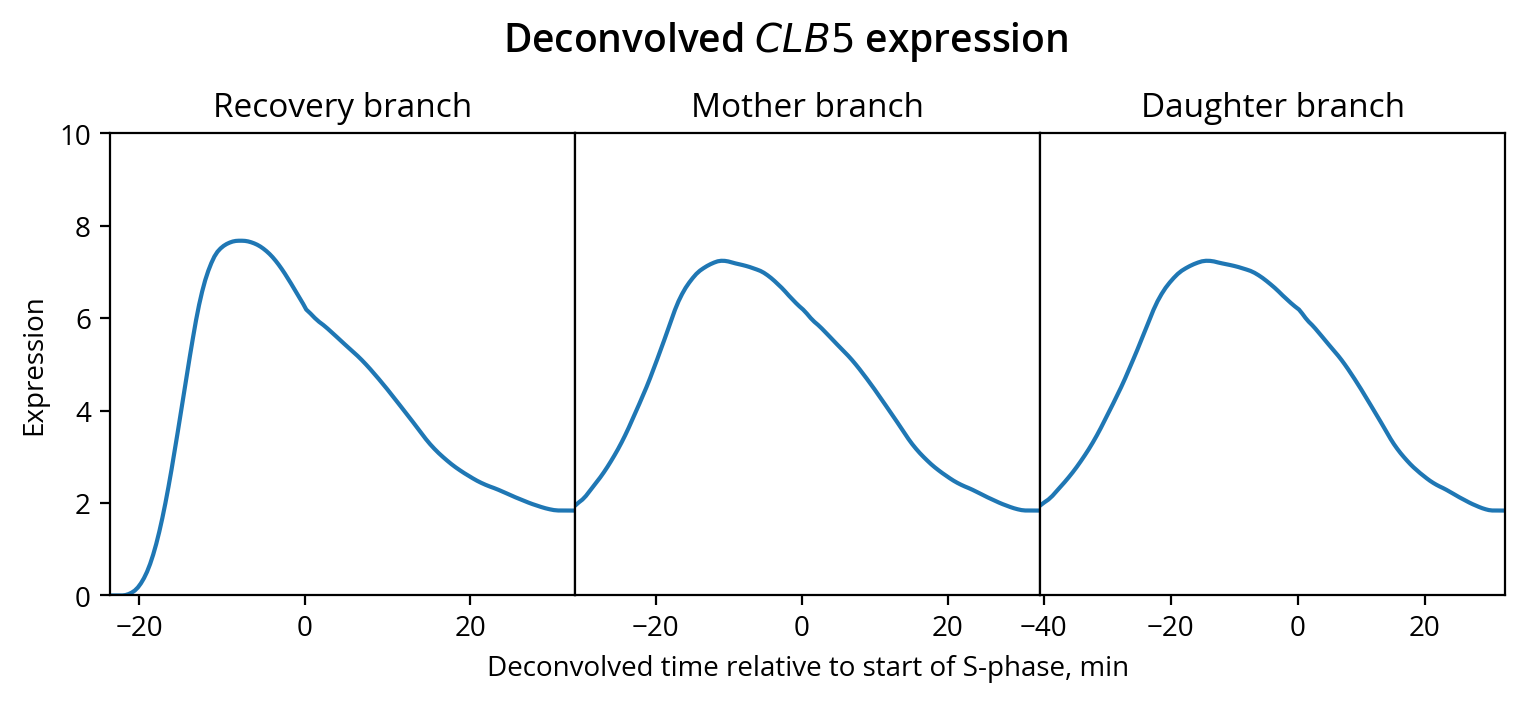

In [7]:
from src.config import get_average_timepoints_for_branch

# Retrieve the average timepoints (of replicates 1 and 2) for each branch
# for plotting
i_tps = get_average_timepoints_for_branch(config1, config2, 'i')
t_tps = get_average_timepoints_for_branch(config1, config2, 't')
b_tps = get_average_timepoints_for_branch(config1, config2, 'b')

# Plot the deconvolved branches for the expression
plt.figure(figsize=(9, 3))
plt.subplot(1, 3, 1)
plt.plot(i_tps, clb5_f[config1.i_indices()])
plt.ylim(0, 10)
plt.xlim(i_tps[0], i_tps[-1])
plt.ylabel("Expression")
plt.title("Recovery branch")

plt.subplot(1, 3, 2)
plt.plot(t_tps, clb5_f[config1.t_indices()])
plt.ylim(0, 10)
plt.xlim(t_tps[0], t_tps[-1])
plt.yticks([])
plt.xlabel("Deconvolved time relative to start of S-phase, min")
plt.title("Mother branch")

plt.subplot(1, 3, 3)
plt.plot(b_tps, clb5_f[config1.b_indices()])
plt.ylim(0, 10)
plt.xlim(b_tps[0], b_tps[-1])
plt.yticks([])
plt.title("Daughter branch")

plt.suptitle("Deconvolved $\\it{CLB5}$ expression", fontweight='demi', fontsize=14, y=1.07)
plt.subplots_adjust(wspace=0)


In [8]:
from src.expression_chromatin_plots import DeconvolutionChromatinExpressionPlotter
from src.ChromatinRNALocusPlotter import SingleBranchChromatinPlotter
from src.rna_pileup_plotter import RNASeqPileupPlotter
from pipeline.transcription_processor import ExpressionAnalysisProcessor
from src.deconvolved_tpm_plotter import DeconvolvedTPMPlotter

# For locus plotting
expression_processor = ExpressionAnalysisProcessor(example_output_dir)
expression_processor.setup_data_loaders()
expression_processor.load_deconvolved_expression()
tpm_plotter = DeconvolvedTPMPlotter(expression_processor.expression_data,
    expression_processor.all_transcripts_set)
rna_plotter = RNASeqPileupPlotter(example_output_dir)

Loaded 1 transcripts
  1 genic transcripts
  0 non-genic transcripts
Loading deconvolved gene expression data...
Loading deconvolved expression files, n= 1
Loaded expression data: 1 transcripts, 257 timepoints


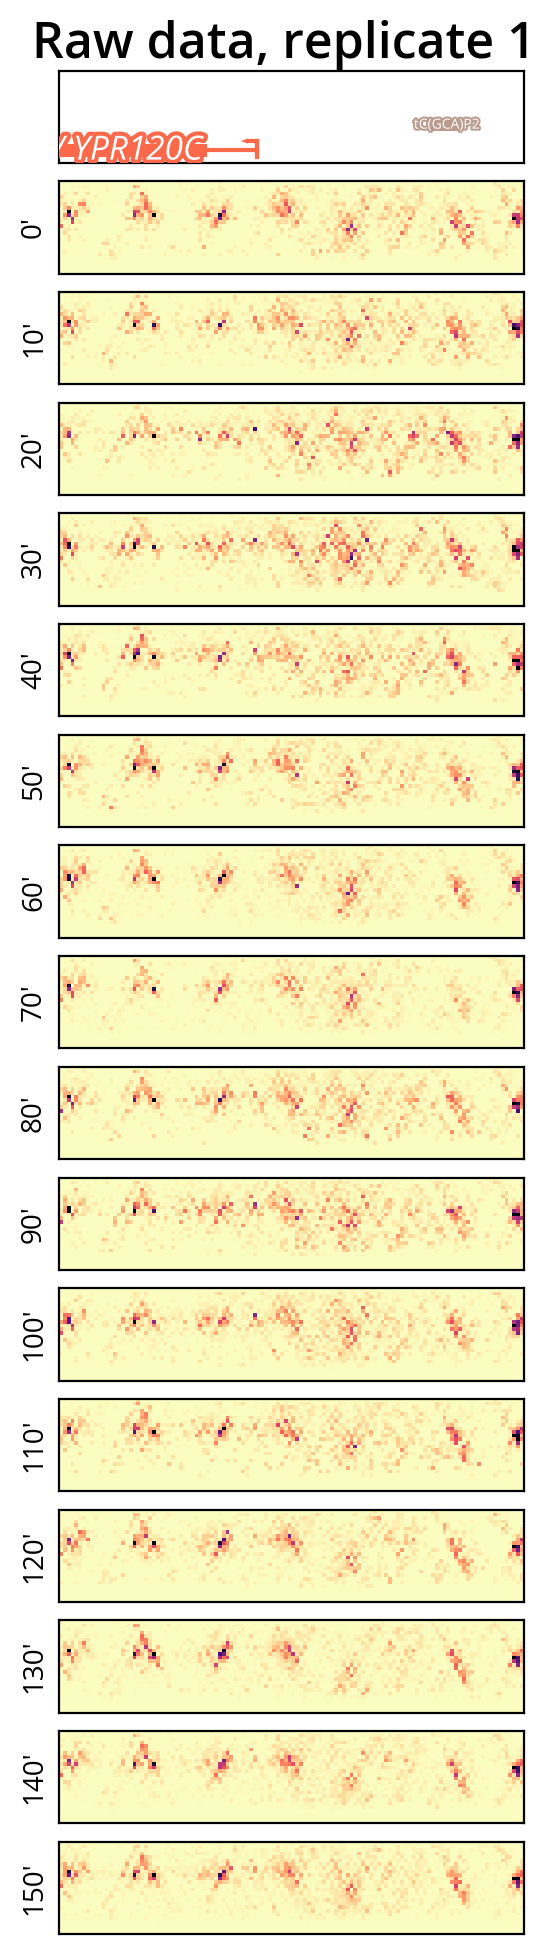

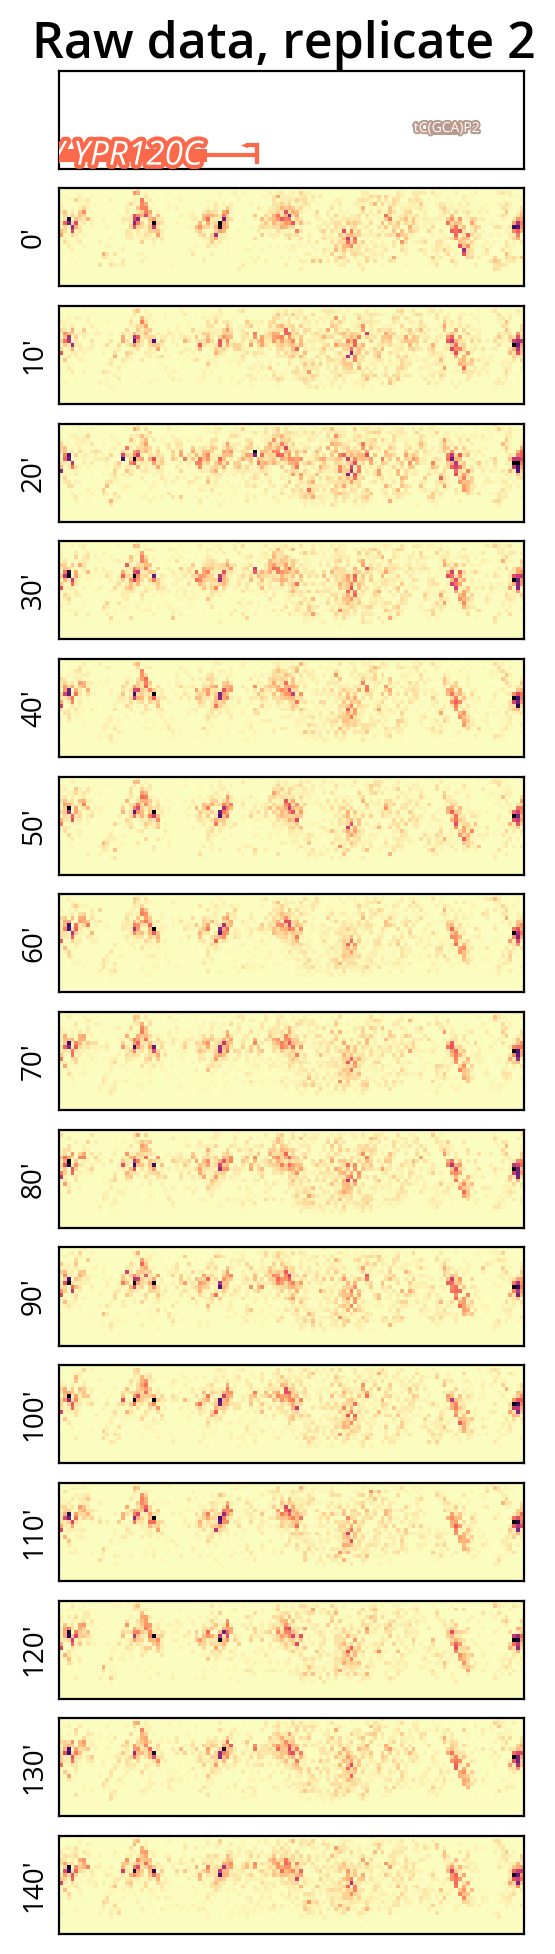

In [9]:
# Plot the raw chromatin data for each replicate for comparison
fig = combined_model.chrom1_model.plot_raw_data(figsize=(3, 11))
fig = combined_model.chrom2_model.plot_raw_data(figsize=(3, 11))

Creating directory: output/example/rna_seq_intermediate...Directory exists. Skipping.
Creating directory: output/example/rna_seq_intermediate/reads...Directory exists. Skipping.
Creating directory: output/example/rna_seq_intermediate/pileups...Directory exists. Skipping.
Initialized RNASeqIntermediateManager for chromosome 16
Intermediate directory: output/example/rna_seq_intermediate
Loaded pileups from watson_rna_seq_pileup_rep1_chr16.h5, crick_rna_seq_pileup_rep1_chr16.h5
Shape: (16, 1200) (timepoints x positions)
Loaded pileups from watson_rna_seq_pileup_rep2_chr16.h5, crick_rna_seq_pileup_rep2_chr16.h5
Shape: (14, 1200) (timepoints x positions)


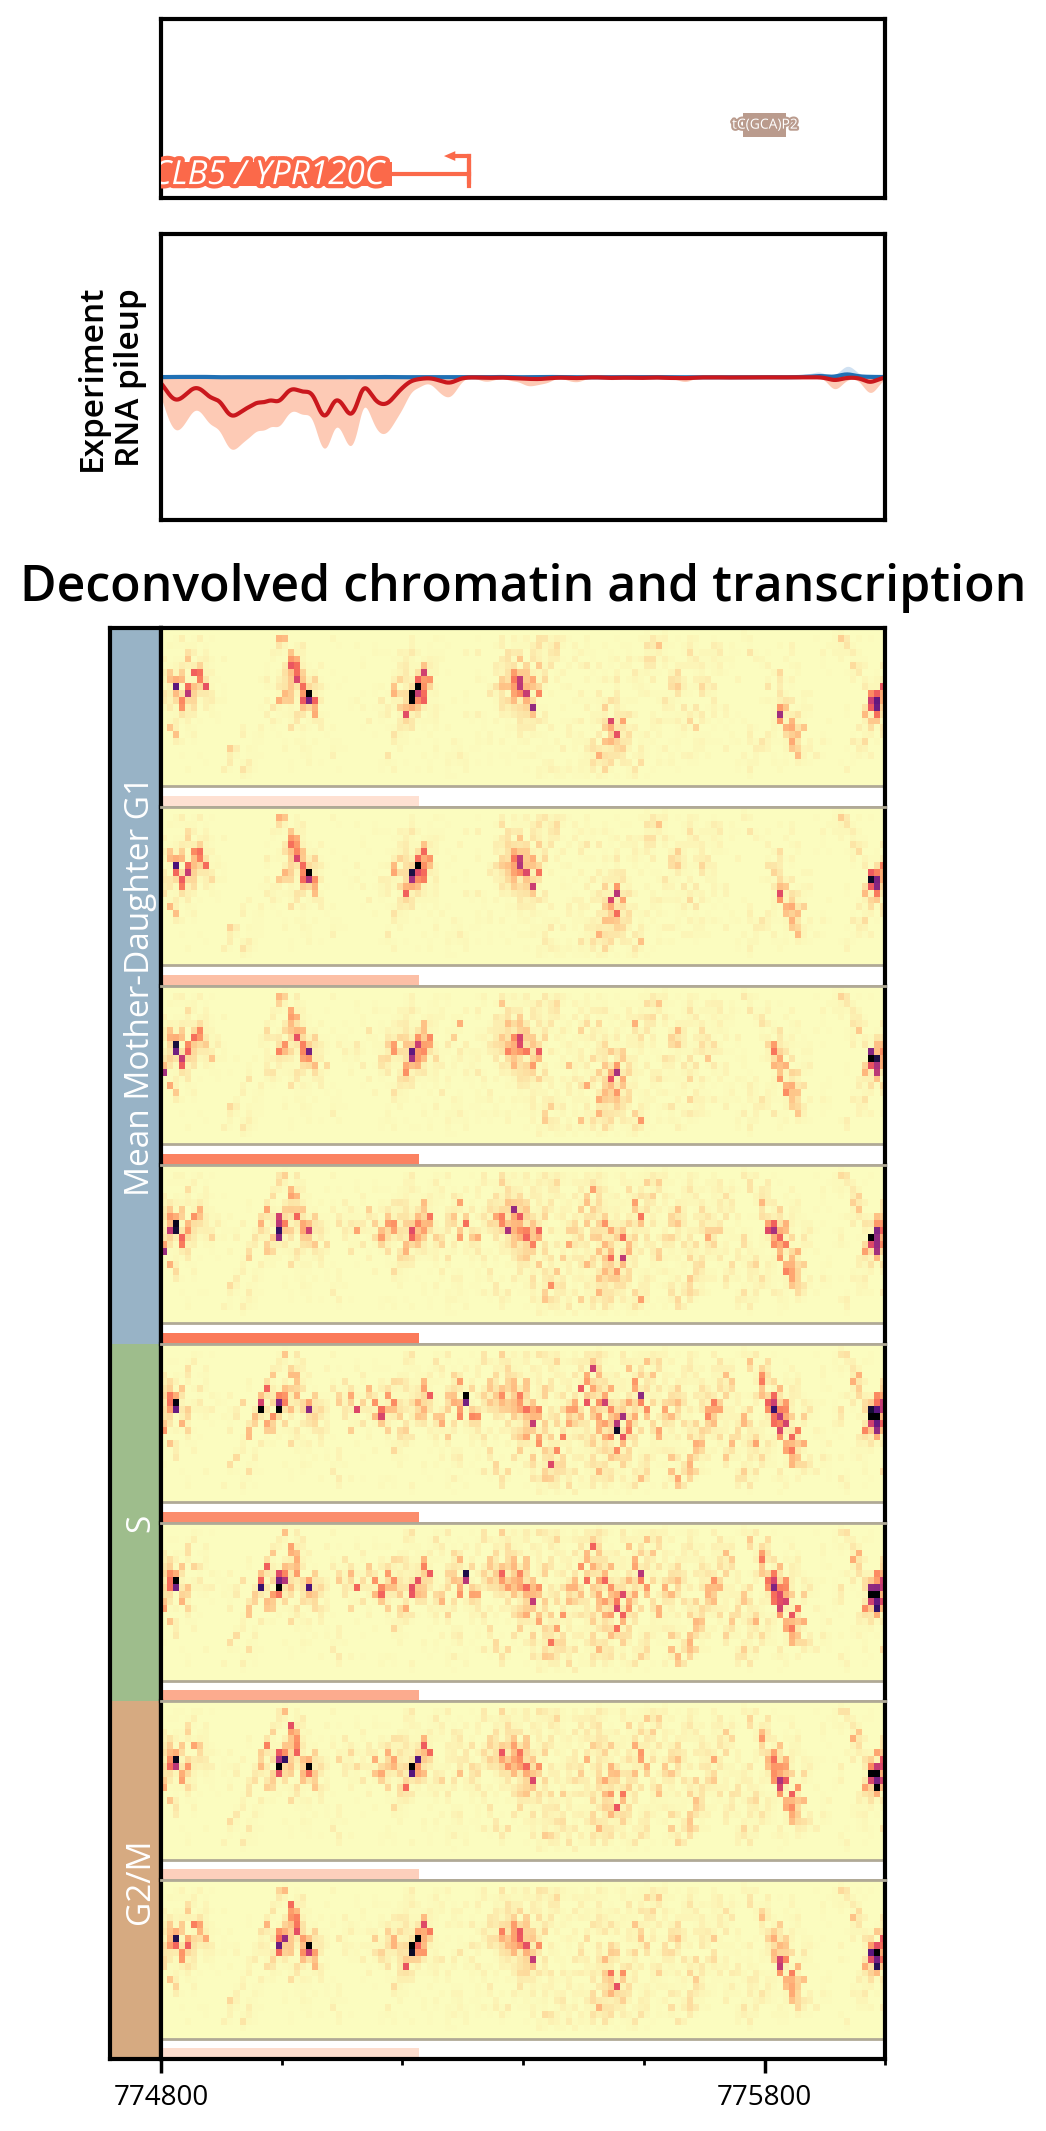

In [10]:
# Plot the deconvolved chromatin within the window
plotter = SingleBranchChromatinPlotter(
    outdir=None,
    config1=config1,
    figsize=(5, 12),
    branch_type='mean_mother_daughter',
    title='',
    rna_plotter=rna_plotter,
    deconvolved_tpm_plotter=tpm_plotter,
    plot_index_labels=False
)

img_shape = combined_model.chrom1_model.image_shape
plotter.set_chrom_span(chrom, mnase_span)
plotter.set_chromatin_data(combined_model.F.reshape(-1, img_shape[0], img_shape[1]))

fig = plotter.plot()